In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-retail/Online Retail.xlsx


In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from collections import Counter
import datetime as dt

In [3]:
df = pd.read_excel("/kaggle/input/online-retail/Online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
df['CustomerID'] = df['CustomerID'].fillna(99999)
df.dropna(subset=['Description'], inplace=True)
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 540455 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    540455 non-null  object        
 1   StockCode    540455 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     540455 non-null  int64         
 4   InvoiceDate  540455 non-null  datetime64[ns]
 5   UnitPrice    540455 non-null  float64       
 6   CustomerID   540455 non-null  float64       
 7   Country      540455 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 37.1+ MB
None
            Quantity                    InvoiceDate      UnitPrice  \
count  540455.000000                         540455  540455.000000   
mean        9.603129  2011-07-04 16:20:42.947035392       4.623519   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000        

In [8]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicated Rows: {duplicate_rows}")

Duplicated Rows: 5268


In [9]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df_clean = df[~df['InvoiceNo'].str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print(f"Original Size: {len(df)}")
print(f"Size After Cleaning: {len(df_clean)}")

Original Size: 540455
Size After Cleaning: 530104


In [10]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
customer_clv = df_clean.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_clv.columns = ['CustomerID', 'TotalSpending_CLV']

customer_clv = customer_clv.sort_values(by='TotalSpending_CLV', ascending=False)
print(customer_clv.iloc[1:10])

      CustomerID  TotalSpending_CLV
1689     14646.0          280206.02
4201     18102.0          259657.30
3728     17450.0          194550.79
3008     16446.0          168472.50
1879     14911.0          143825.06
55       12415.0          124914.53
1333     14156.0          117379.63
3771     17511.0           91062.38
2702     16029.0           81024.84


In [11]:
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm = rfm[rfm['CustomerID'] != 99999]
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [12]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 0 = Monday, 6 = Sunday
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['DayName'] = df_clean['InvoiceDate'].dt.day_name() 
df_clean['Month'] = df_clean['InvoiceDate'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_clean['Season'] = df_clean['Month'].apply(get_season)

print(df_clean[['InvoiceDate', 'Hour', 'DayName', 'Month', 'Season']].head())

          InvoiceDate  Hour    DayName  Month  Season
0 2010-12-01 08:26:00     8  Wednesday     12  Winter
1 2010-12-01 08:26:00     8  Wednesday     12  Winter
2 2010-12-01 08:26:00     8  Wednesday     12  Winter
3 2010-12-01 08:26:00     8  Wednesday     12  Winter
4 2010-12-01 08:26:00     8  Wednesday     12  Winter


In [13]:
df_clean['Is_UK'] = (df_clean['Country'] == 'United Kingdom').astype(int)

In [14]:
all_words = " ".join(df_clean['Description']).split()
common_words = Counter(all_words).most_common(20)

import pandas as pd
top_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
print(top_words_df)

         Word  Frequency
0         SET      53639
1          OF      52637
2         BAG      51186
3         RED      42079
4       HEART      38241
5   RETROSPOT      34400
6     VINTAGE      33247
7      DESIGN      29544
8        PINK      29129
9   CHRISTMAS      24840
10        BOX      23826
11       CAKE      20938
12      JUMBO      20875
13      METAL      20556
14      WHITE      20376
15       BLUE      18947
16      LUNCH      18240
17          3      18078
18       SIGN      16791
19    HANGING      16647


In [15]:
df_clean['Is_Vintage'] = df_clean['Description'].str.contains('VINTAGE').astype(int)
df_clean['Is_Set'] = df_clean['Description'].str.contains('SET').astype(int)
df_clean['Is_Retro'] = df_clean['Description'].str.contains('RETROSPOT').astype(int)
df_clean['Is_Heart'] = df_clean['Description'].str.contains('HEART').astype(int)

colors = ['RED', 'BLUE', 'GREEN', 'WHITE', 'PINK', 'SILVER', 'GOLD']

for color in colors:
    df_clean[f'Color_{color}'] = df_clean['Description'].str.contains(color).astype(int)

print(df_clean[['Description', 'Is_Vintage', 'Is_Set', 'Color_RED','Is_Retro','Is_Heart']].head())

                           Description  Is_Vintage  Is_Set  Color_RED  \
0   WHITE HANGING HEART T-LIGHT HOLDER           0       0          0   
1                  WHITE METAL LANTERN           0       0          0   
2       CREAM CUPID HEARTS COAT HANGER           0       0          0   
3  KNITTED UNION FLAG HOT WATER BOTTLE           0       0          0   
4       RED WOOLLY HOTTIE WHITE HEART.           0       0          1   

   Is_Retro  Is_Heart  
0         0         1  
1         0         0  
2         0         1  
3         0         0  
4         0         1  


In [16]:
features = ['Recency', 'Frequency', 'Monetary']
rfm_data = rfm[features]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features)

print(rfm_scaled_df.head())

    Recency  Frequency  Monetary
0  2.334574  -0.425097  8.358668
1 -0.905340   0.354417  0.250966
2 -0.175360  -0.035340 -0.028596
3 -0.735345  -0.425097 -0.033012
4  2.174578  -0.425097 -0.191347


In [17]:
country_counts = df_clean.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

country_perc = (country_counts / country_counts.sum()) * 100

print("Top 5 Countries: ")
print(country_perc.head())

Top 5 Countries: 
Country
United Kingdom    90.034443
Germany            2.158439
France             2.020666
Spain              0.688863
Belgium            0.574053
Name: CustomerID, dtype: float64


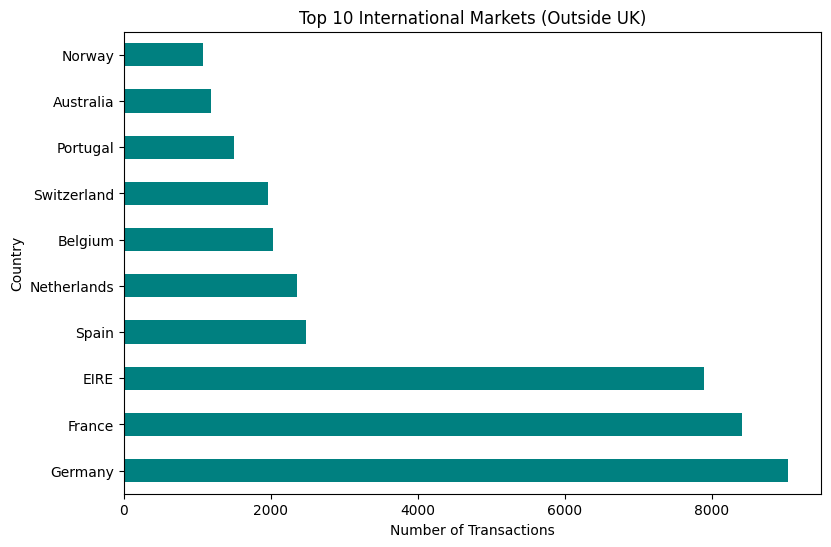

In [18]:
top_countries = df_clean[df_clean['Country'] != 'United Kingdom']['Country'].value_counts().head(10)

top_countries.plot(kind='barh', figsize=(9, 6), color='teal')
plt.title('Top 10 International Markets (Outside UK)')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.show()

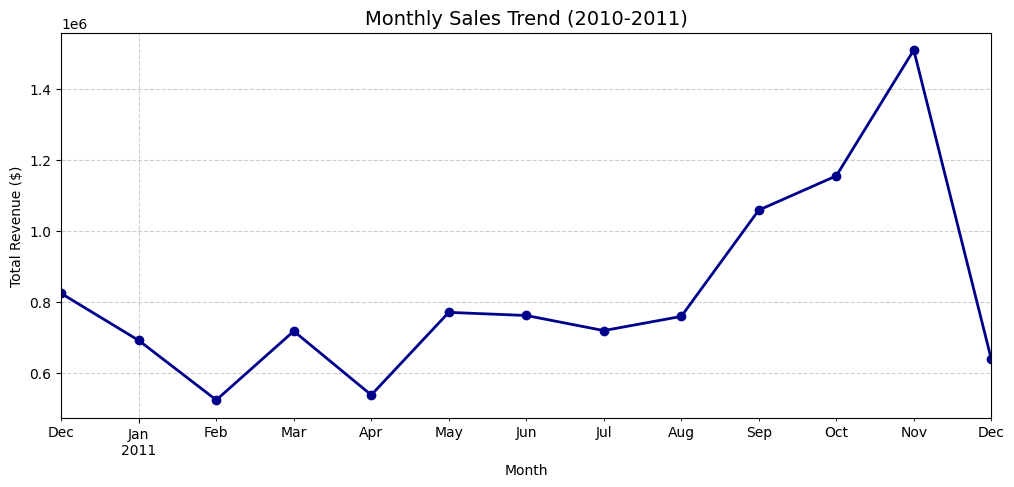

In [19]:
monthly_sales = df_clean.set_index('InvoiceDate')['TotalPrice'].resample('MS').sum()
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='darkblue', linewidth=2)

plt.title('Monthly Sales Trend (2010-2011)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [20]:
customer_spending = rfm.sort_values(by='Monetary', ascending=False)
top_20_cutoff = int(len(customer_spending) * 0.20)
top_20_customers = customer_spending.iloc[:top_20_cutoff]

top_20_revenue = top_20_customers['Monetary'].sum()
total_revenue = rfm['Monetary'].sum()
pareto_ratio = (top_20_revenue / total_revenue) * 100

print(f"The richest 20% of customers contributed : {pareto_ratio:.2f}% From the total profits")

The richest 20% of customers contributed : 74.59% From the total profits


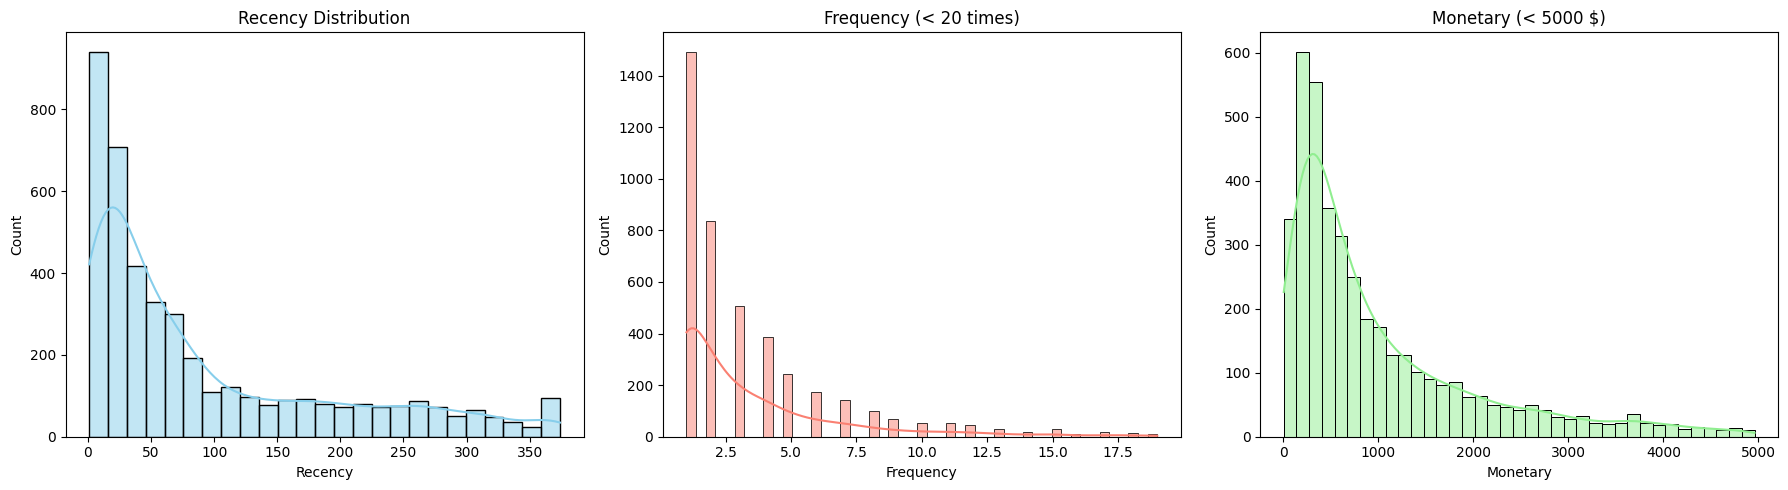

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Recency Distribution')

sns.histplot(rfm[rfm['Frequency'] < 20]['Frequency'], kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Frequency (< 20 times)')

sns.histplot(rfm[rfm['Monetary'] < 5000]['Monetary'], kde=True, ax=ax[2], color='lightgreen')
ax[2].set_title('Monetary (< 5000 $)')

plt.tight_layout()
plt.show()

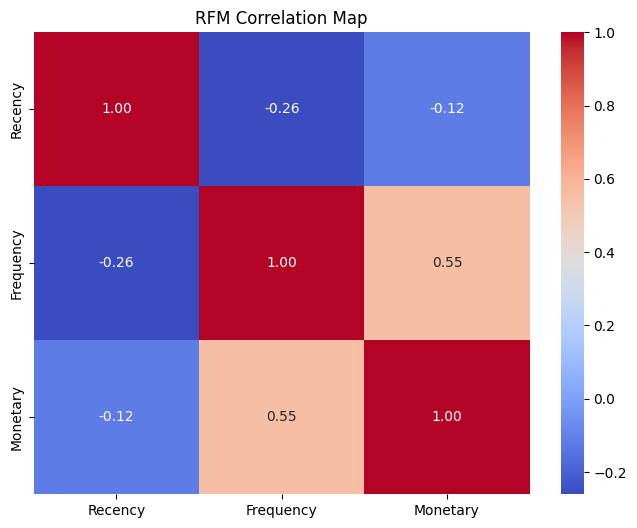

In [22]:
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('RFM Correlation Map')
plt.show()

In [23]:
popular_products = df_clean.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).sort_values(by='Quantity', ascending=False) 

top_10_products = popular_products.head(10).reset_index()
print(top_10_products)

  StockCode                         Description  Quantity  TotalPrice
0     23843         PAPER CRAFT , LITTLE BIRDIE     80995   168469.60
1     23166      MEDIUM CERAMIC TOP STORAGE JAR     78033    81700.92
2     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047    13841.85
3    85099B             JUMBO BAG RED RETROSPOT     48474    94340.05
4    85123A  WHITE HANGING HEART T-LIGHT HOLDER     37599   104340.29
5     22197                      POPCORN HOLDER     36761    34298.87
6     84879       ASSORTED COLOUR BIRD ORNAMENT     36461    59094.93
7     21212     PACK OF 72 RETROSPOT CAKE CASES     36419    21259.10
8     23084                  RABBIT NIGHT LIGHT     30788    66964.99
9     22492             MINI PAINT SET VINTAGE      26633    16937.82


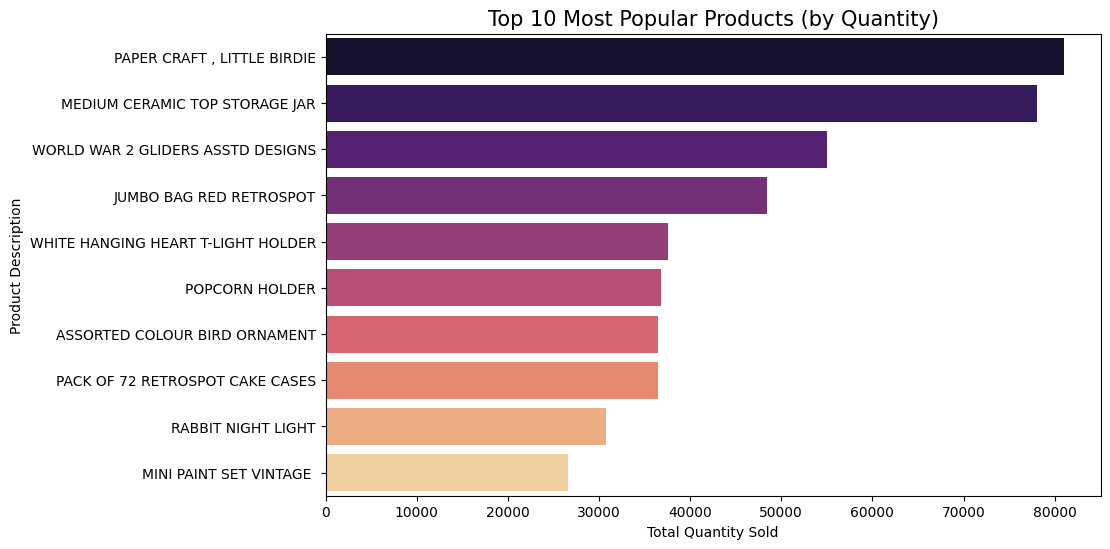

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_products, x='Quantity', y='Description', palette='magma')

plt.title('Top 10 Most Popular Products (by Quantity)', fontsize=15)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.show()

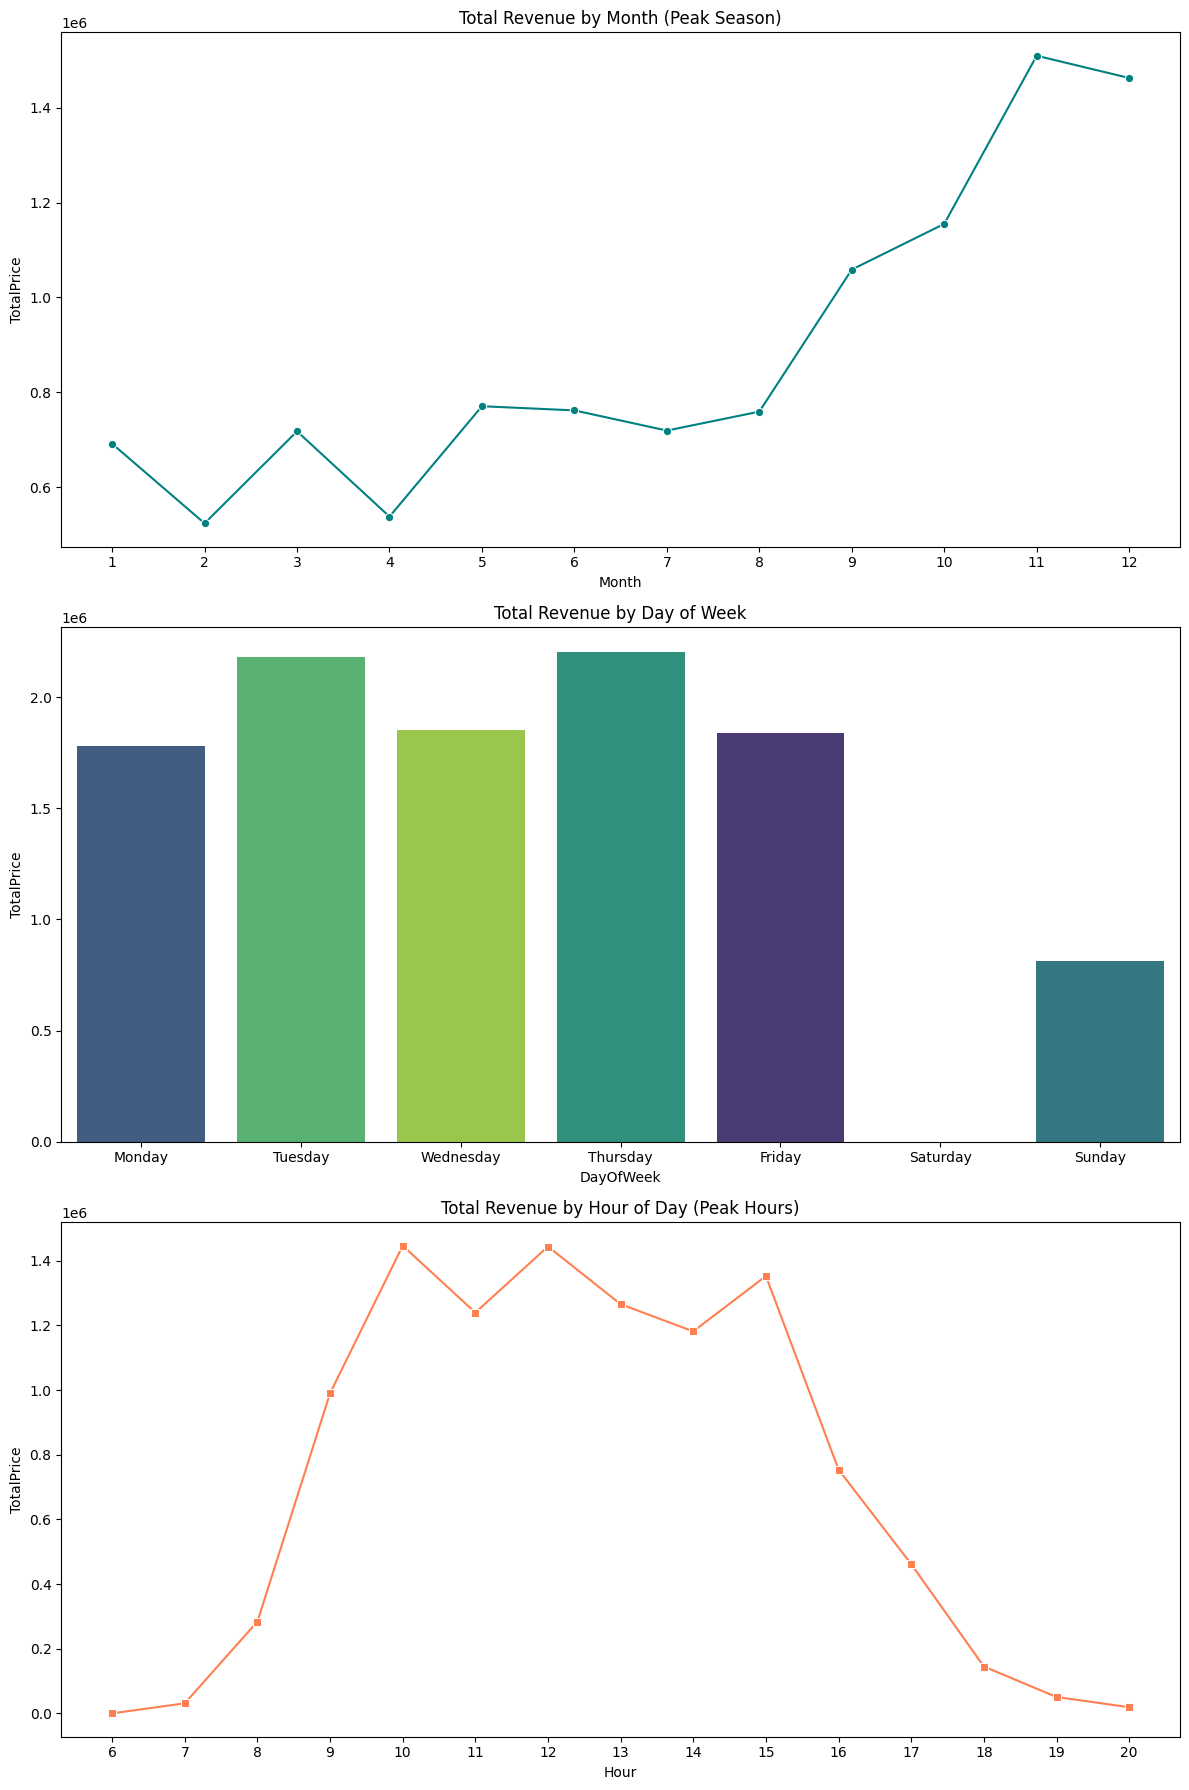

In [25]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

fig, ax = plt.subplots(3, 1, figsize=(12, 18))

sns.lineplot(data=df_clean.groupby('Month')['TotalPrice'].sum().reset_index(), 
             x='Month', y='TotalPrice', marker='o', ax=ax[0], color='teal')
ax[0].set_title('Total Revenue by Month (Peak Season)')
ax[0].set_xticks(range(1, 13))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df_clean.groupby('DayOfWeek')['TotalPrice'].sum().reset_index(), 
            x='DayOfWeek', y='TotalPrice', order=days_order, ax=ax[1], palette='viridis', hue='DayOfWeek', legend=False)
ax[1].set_title('Total Revenue by Day of Week')

sns.lineplot(data=df_clean.groupby('Hour')['TotalPrice'].sum().reset_index(), 
             x='Hour', y='TotalPrice', marker='s', ax=ax[2], color='coral')
ax[2].set_title('Total Revenue by Hour of Day (Peak Hours)')
ax[2].set_xticks(range(6, 21)) 

plt.tight_layout()
plt.show()

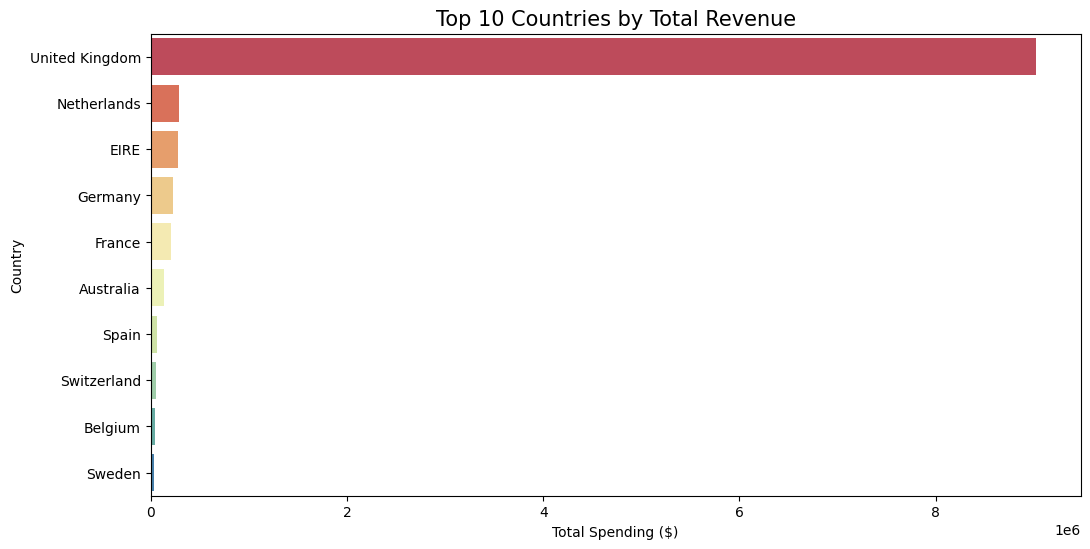

In [26]:
country_spending = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
top_countries = country_spending.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='TotalPrice', y='Country', hue='Country', palette='Spectral', legend=False)
plt.title('Top 10 Countries by Total Revenue', fontsize=15)
plt.xlabel('Total Spending ($)')
plt.ylabel('Country')
plt.show()

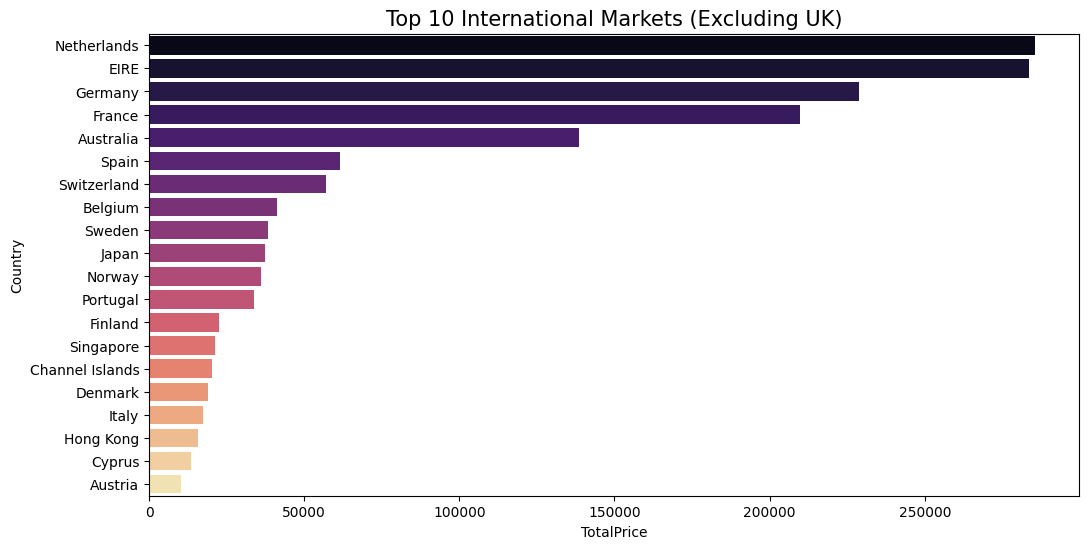

In [27]:
other_countries = country_spending[country_spending['Country'] != 'United Kingdom'].iloc[0:20]

plt.figure(figsize=(12, 6))
sns.barplot(data=other_countries, x='TotalPrice', y='Country', hue='Country', palette='magma', legend=False)
plt.title('Top 10 International Markets (Excluding UK)', fontsize=15)
plt.show()

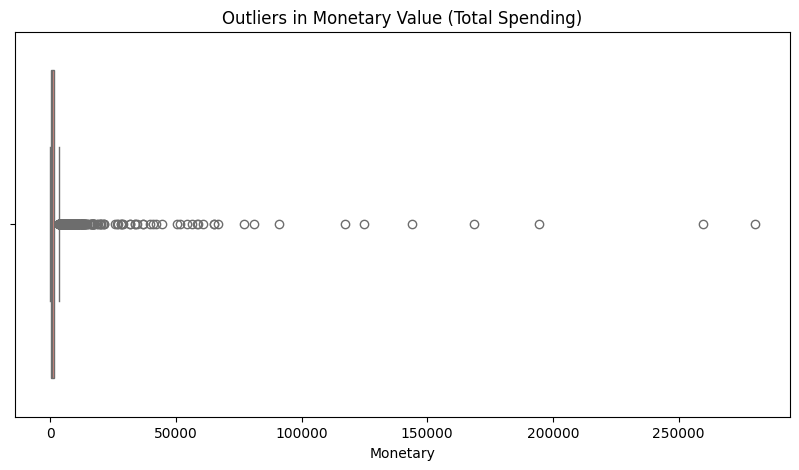

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=rfm['Monetary'], color='salmon')
plt.title('Outliers in Monetary Value (Total Spending)')
plt.show()

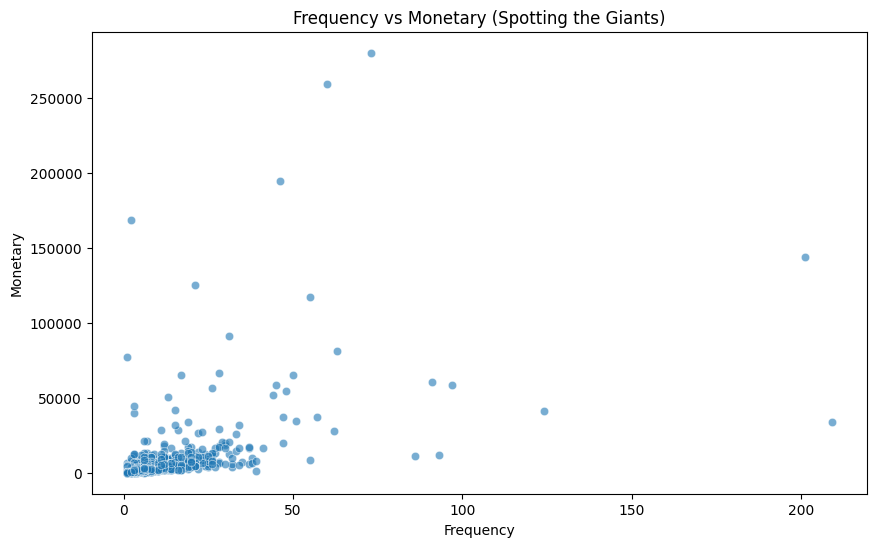

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', alpha=0.6)
plt.title('Frequency vs Monetary (Spotting the Giants)')
plt.show()

In [30]:
top_spenders = rfm.sort_values('Monetary', ascending=False).head(5)
print("Top 5 Outliers (The Giants):")
print(top_spenders[['Monetary', 'Frequency']])

Top 5 Outliers (The Giants):
       Monetary  Frequency
1689  280206.02         73
4201  259657.30         60
3728  194550.79         46
3008  168472.50          2
1879  143825.06        201


In [31]:
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rfm_clean = rfm[(rfm['Monetary'] >= lower_bound) & (rfm['Monetary'] <= upper_bound)]

print(f"Data Before Deleting: {len(rfm)}")
print(f"Data After Deleting: {len(rfm_clean)}")

Data Before Deleting: 4338
Data After Deleting: 3911
